# Trabajo lab 2 Sandra Blázquez Arriero

## Importar los datos:

Lo primero que tenemos que realizar es importar los datos a nuestro colab, para ello lo primero que tenemos que hacer es unir nuestra cuenta de google drive donde tenemos los datos con el colab para poder acceder a ellos.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Una vez tenemos el drive unido al colab tenemos que indicar donde tenemos los datos que vamos a utilizar y vemos que tenemos dentro de esa carpeta:

In [3]:
import os

folder_path = "/content/drive/MyDrive/dataset/dataset"
files = os.listdir(folder_path)
print(files)


['participants.xlsx', 'data']


Como podemos ver tenemos un xlsx y una carpeta, lo primero que queremos es ver que tenemos en el participants.xlsx:

In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/dataset/dataset/participants.xlsx"
data = pd.read_excel(file_path)
print(data.head())


  subject  age gender  Weight  height  foot_length  knee_height  \
0  sub_01   27      M    74.0   175.0         28.0         53.0   
1  sub_02   29      M    98.0   165.0         28.0         49.0   
2  sub_03   42      M    78.4   184.0         29.0         57.0   
3  sub_04   24      M    58.1   175.0         26.5         53.5   
4  sub_05   39      M    63.6   171.0         26.0         54.0   

   shoulder_height  shoulder_width  elbow span  wrist span  
0            144.0            42.0          92       140.0  
1            139.0            44.0          90       137.0  
2            157.0            38.0          87       142.0  
3            145.5            40.0          87       131.0  
4            136.5            40.5          89       143.0  


## Combinar los datos:

Ahora, como en la carpeta de data tenemos más carpetas llamadas sub_XX, siendo XX desde el 01 hasta el 23, y queremos ver todos los datos, vamos a combinar todos los datos en un unico csv, ya que dentro de cada carpeta tenemos unos archivos csv llamados rec_X.csv, siendo X desde el 0 hasta el 10 (menos en el caso del sub_09 que es solo hasta el 9), entonces con el siguiente codigo combinamos todos los csv en uno solo pero con un indice extra:

In [5]:
import os
import pandas as pd

# Ruta de la carpeta principal que contiene las subcarpetas
main_folder_path = "/content/drive/MyDrive/dataset/dataset/data"

# Lista para almacenar los DataFrames
dataframes = []

# Iterar sobre las subcarpetas
for i in range(1, 24):
    subfolder_name = f"sub_{i:02d}"
    subfolder_path = os.path.join(main_folder_path, subfolder_name)

    # Verificar si la subcarpeta existe
    if os.path.exists(subfolder_path):
        # Iterar sobre los archivos CSV en la subcarpeta
        for j in range(11):
            csv_file_name = f"rec_{j}.csv"
            csv_file_path = os.path.join(subfolder_path, csv_file_name)

            # Leer el archivo CSV y añadir la columna 'n'
            if os.path.exists(csv_file_path):
                df = pd.read_csv(csv_file_path)
                df['n'] = i
                dataframes.append(df)
            else:
                print(f"Archivo no encontrado: {csv_file_path}")
    else:
        print(f"Subcarpeta no encontrada: {subfolder_path}")

# Combinar todos los DataFrames en uno solo
if dataframes:
    combined_df = pd.concat(dataframes, ignore_index=True)
    # Guardar el DataFrame combinado en un archivo CSV
    combined_df.to_csv("/content/drive/MyDrive/dataset/combined_data.csv", index=False)
    print("Archivos combinados y guardados exitosamente.")
else:
    print("No se encontraron archivos CSV para combinar.")


Archivo no encontrado: /content/drive/MyDrive/dataset/dataset/data/sub_09/rec_10.csv
Archivos combinados y guardados exitosamente.


Y ahora ya si podemos ver que tenemos en el csv de los datos combinados:

In [6]:
import pandas as pd

# Cargar el archivo CSV combinado
combined_file_path = "/content/drive/MyDrive/dataset/combined_data.csv"
combined_df = pd.read_csv(combined_file_path)

# Mostrar las primeras filas del DataFrame combinado
print(combined_df.head())


   pelvis_x   pelvis_y  pelvis_z      L5_x       L5_y      L5_z      L3_x  \
0  5.290658  10.270959  0.928399  5.295636  10.278010  1.024168  5.294113   
1  5.290281  10.270359  0.928462  5.295316  10.277418  1.024227  5.293876   
2  5.289904  10.269758  0.928525  5.294997  10.276826  1.024286  5.293640   
3  5.289517  10.269149  0.928582  5.294664  10.276223  1.024340  5.293392   
4  5.289107  10.268520  0.928633  5.294305  10.275599  1.024388  5.293121   

        L3_y      L3_z     T12_x  ...  footLeft_x  footLeft_y  footLeft_z  \
0  10.278961  1.128732  5.299640  ...    5.385067   10.221425    0.094657   
1  10.278291  1.128793  5.299482  ...    5.385006   10.221376    0.094694   
2  10.277622  1.128854  5.299325  ...    5.384945   10.221327    0.094731   
3  10.276951  1.128909  5.299158  ...    5.384901   10.221278    0.094760   
4  10.276274  1.128959  5.298974  ...    5.384884   10.221229    0.094778   

   toeLeft_x  toeLeft_y  toeLeft_z     vel_x     vel_y     vel_z  n  
0   

Ahora que tenemos los datos cargados correctamente y ya combinados todos entre ellos, podemos empezar a realizar las diversas actividades que se nos piden:

## Eliminar la correlación entre articulaciones:

Primero de todo ponemos todos los imports que son necesarios para esta primera parte:

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import os
from sklearn.preprocessing import StandardScaler

Creamos una copia del dataframe para poder realizar las modificaciones sin ningún tipo de problema:

In [7]:
resta = combined_df.copy()

Y ahora realizamos la resta de la posición de la pelvís al resto de articulaciones y calculamos la matriz de correlación para los nuevos datos ya ajustados:

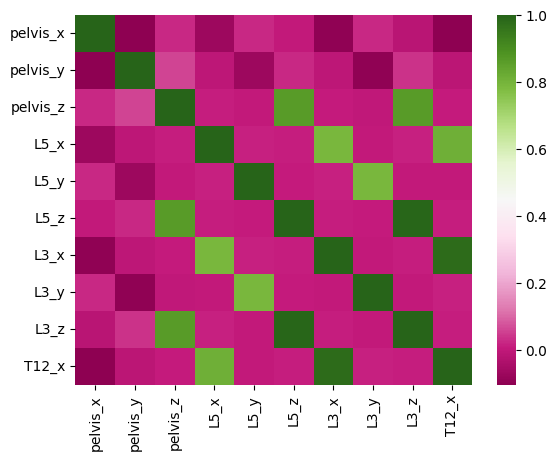

In [8]:
for i in range(3):
    resta.iloc[:, i+3:-3:3] -= combined_df.iloc[:, i:i+1].to_numpy()

corrs = resta.iloc[:, :10].corr()

sns.heatmap(corrs, cmap='PiYG')
plt.show()

Esta matriz de correlación nos permite observar cómo las posiciones relativas de las articulaciones se han desacoplado de la posición general de la pelvis, destacando la variabilidad propia de cada articulación.

## Ventaneo:

Para realizar el ventaneo lo primero tenemos que indicar la frecuencia de muestra y la duración (en segundos) de cada ventana, en el enunciado se nos indica que tienen que ser de 4 segundos, por lo tanto, se realizarán de duración 4:

In [9]:
freq = 60
segundos = 4
ventana = freq * segundos

Ahora tenemos que crear una lista para poder almacenar las ventanas que vamos generando:

In [10]:
lista_ventanas = []

Ahora segmentamos el conjunto de datos en ventanas de 4 segundos que serán guardadas en la anterior lista creada:

In [11]:
for i in range(0, len(combined_df) - ventana + 1, ventana):
    lista_ventanas.append(combined_df.iloc[i:i + ventana].to_numpy())

Por último, convertimos la lista de ventanas en un array de numpy para poder mostrar ese array:

In [12]:
lista_ventanas = np.array(lista_ventanas)

print(lista_ventanas.shape)

(3766, 240, 73)


## Normalización:

Lo primero que vamos a hacer es normalizar los datos y crear una nueva lista para almacenar esta vez las ventanas pero con la normalización realizada:

In [14]:
scaler = StandardScaler()

ventanas_normalizadas = []

Ahora si vamos a realizar la normalización de cada uno de los puntos que tenemos de cada persona en cada persona y además vamos a hacer que todas empiecen en 0, tal y como se pide en el enunciado (todas empiezan desde la posición x=0, y=0 y z=0):

In [22]:
columns = combined_df.columns
for ventana in lista_ventanas:
    # Normalización de los puntos
    scaled_data = scaler.fit_transform(ventana)
    scaled_data = pd.DataFrame(scaled_data, columns=columns)

    # que todas empiecen desde x=0, y=0, z=0
    pelvis_columns = ['pelvis_x', 'pelvis_y', 'pelvis_z']
    for col in pelvis_columns:
        scaled_data[col] -= scaled_data[col].iloc[0]

    ventanas_normalizadas.append(scaled_data)

Al terminar la normalización ahora convertimos la lista en un dataframe y nos lo guardamos por si acaso.

In [23]:
normalized_df = pd.concat(ventanas_normalizadas, ignore_index=True)

# Guardar el DataFrame normalizado en un archivo CSV
normalized_file_path = "/content/drive/MyDrive/dataset/normalized_combined_data.csv"
normalized_df.to_csv(normalized_file_path, index=False)

print("Datos normalizados y guardados exitosamente.")

Datos normalizados y guardados exitosamente.


Y por último lo imprimimos para ver que datos tenemos:

In [24]:
normalized_file_path = "/content/drive/MyDrive/dataset/normalized_combined_data.csv"
normalized_df = pd.read_csv(normalized_file_path)

print(normalized_df.head())

   pelvis_x  pelvis_y  pelvis_z      L5_x      L5_y      L5_z      L3_x  \
0  0.000000  0.000000  0.000000  0.833189  0.864294  0.653662  0.839323   
1 -0.000827 -0.000626  0.004648  0.832490  0.863679  0.657992  0.838807   
2 -0.001654 -0.001252  0.009296  0.831793  0.863064  0.662322  0.838293   
3 -0.002504 -0.001887  0.013502  0.831066  0.862438  0.666286  0.837754   
4 -0.003403 -0.002543  0.017265  0.830281  0.861791  0.669809  0.837164   

       L3_y      L3_z     T12_x  ...  footLeft_x  footLeft_y  footLeft_z  \
0  0.874539  0.716193  0.847213  ...    0.751475    0.779194   -0.549801   
1  0.873846  0.720461  0.846870  ...    0.751347    0.779145   -0.549009   
2  0.873155  0.724729  0.846529  ...    0.751219    0.779097   -0.548216   
3  0.872461  0.728578  0.846167  ...    0.751127    0.779048   -0.547595   
4  0.871761  0.732076  0.845768  ...    0.751092    0.778999   -0.547209   

   toeLeft_x  toeLeft_y  toeLeft_z     vel_x     vel_y     vel_z    n  
0   0.720878   0.761

## Extracción de caracteristicas:

### Media

### Desviación típica:

### Mínimo y máximo:

### Energía de la señal:

###Parámetros de Hjorth:

## Elección de algoritmo:

## Interpretación de resultados: